# <center> Homework 128

In [1]:
import tensorflow_datasets as tfds
from importlib import reload
import tf_data
import tf_model
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.datasets import load_sample_images
import numpy as np
import pandas as pd
from pathlib import Path
import SARIMA_model
from statsmodels.tsa.arima.model import ARIMA
import keras_tuner as kt

2026-02-16 23:19:37.019488: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-16 23:19:37.728165: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-16 23:19:41.073872: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
/home/zdravko/Machine_Learning_Intern/venv/lib/python3.13/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):
2026-02-16 23:19:46.237702: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit

In [2]:
path = Path("datasets/CTA_-_Ridership_-_Daily_Boarding_Totals_20260211.csv")
df = pd.read_csv(path, parse_dates=["service_date"])
df.columns = ["date", "day_type", "bus", "rail", "total"] # shorter names
df = df.sort_values("date").set_index("date")
df = df.drop("total", axis=1) # no need for total, it's just bus + rail
df = df.drop_duplicates() # remove duplicated months (2011-10 and 2014-07)

df['bus'] = df['bus'].str.replace(",", "").astype(float)
df['rail'] = df['rail'].str.replace(",", "").astype(float)

## Task 0

задачите от предишния ден:

    да се тества с по-голям frame
    да се направи wraper на класа ARMA съвместим с класа Model от керас и да се ползва вградения grid search


In [4]:
rail_df = df['rail'].asfreq("D")

train = rail_df.iloc[:5000]
test  = rail_df.iloc[5000:5030]

In [8]:
class ARIMA_TF(tf.keras.Model):
    def __init__(self, data, order, seasonal_order=None, steps=30, **kwargs):
        super().__init__(**kwargs)
        self.steps = steps
        self.arima = ARIMA(data, order=order, seasonal_order=seasonal_order)

    def fit(self, X, y, *args, **kwargs):
        self.arima = self.arima.fit()
        y_pred = self.arima.forecast(self.steps)
        val_mape = ((y - y_pred) / y).abs().mean()
        return {'val_mape': val_mape}

In [6]:
def build_model(hp: kt.HyperParameters):
    p = hp.Int('p', 0, 3)
    d = hp.Int('d', 0, 2)
    q = hp.Int('q', 0, 3)

    P = hp.Int('P', 0, 2)
    D = hp.Int('D', 0, 2)
    Q = hp.Int('Q', 0, 2)
    # s = hp.Choice('s', [7, 28, 7 * 52])

    return ARIMA_TF(train, order=(p, d, q), seasonal_order=(P, D, Q, 7))

In [11]:
search = kt.GridSearch(build_model, 'val_mape', directory="my_dir", project_name="arima")
search.search(X=None, y=test)

Trial 284 Complete [00h 00m 32s]
val_mape: 0.049174101925163125

Best val_mape So Far: 0.03224182684601827
Total elapsed time: 01h 32m 03s

Search: Running Trial #285

Value             |Best Value So Far |Hyperparameter
0                 |0                 |p
2                 |0                 |d
2                 |0                 |q
1                 |0                 |P
1                 |2                 |D
2                 |1                 |Q



KeyboardInterrupt: 

In [14]:
search.get_best_hyperparameters(1)[0].values

{'p': 0, 'd': 0, 'q': 0, 'P': 0, 'D': 2, 'Q': 1}

/home/zdravko/Machine_Learning_Intern/venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'


<Axes: xlabel='date'>

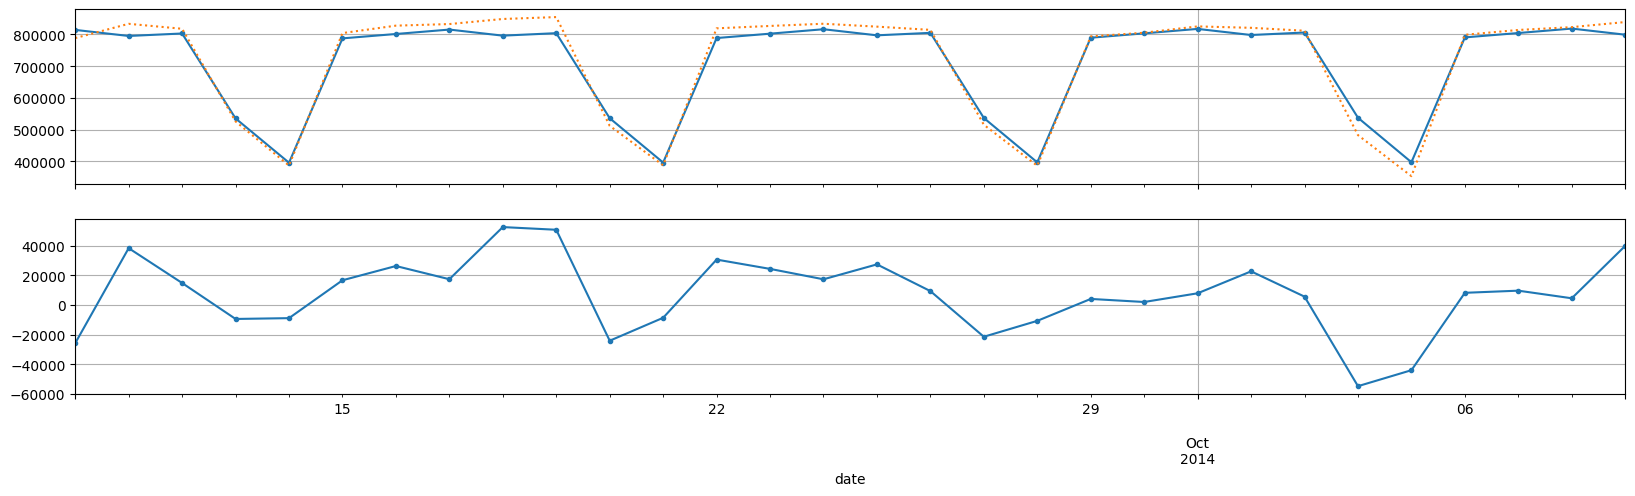

In [15]:
sarima = ARIMA(train, order=(0, 0, 0), seasonal_order=(0, 2, 1, 7)).fit()

y_pred = sarima.forecast(steps=30)
diff = test - y_pred

fig, axs = plt.subplots(2, 1, sharex=True, figsize=(20, 5))

y_pred.plot(ax=axs[0], legend=False, marker=".") 
test.plot(ax=axs[0], grid=True, legend=False, linestyle=":") 

diff.plot(ax=axs[1], grid=True, marker=".")

In [16]:
(diff / test).abs().mean()

np.float64(0.03224182684601827)

### да се тества с по-голям frame

In [17]:
period = slice('2016-01', '2016-12')

df_num = df[['bus', 'rail']].loc[:'2019-12'] / 1e6
df_cat = pd.get_dummies(df['day_type'].shift(-1).loc[:'2019-12']).astype(float)
df_concat = pd.concat([df_num, df_cat], axis=1)

train_ratio = 0.7
train_samples = int(len(df_concat) * train_ratio)

df_bus_rail_train = df_num.iloc[:train_samples]
df_bus_rail_test = df_num.iloc[train_samples:]

df_train, df_test = df_concat.iloc[:train_samples], df_concat.iloc[train_samples:]

frame_length = 7

In [18]:
frame_length = 7

train_ds = tf.keras.utils.timeseries_dataset_from_array(
    df_train.to_numpy(),
    targets=df_num[:train_samples][frame_length:],
    sequence_length=frame_length,
    batch_size=32,
    shuffle=True,
    seed=42
)

test_ds = tf.keras.utils.timeseries_dataset_from_array(
    df_test.to_numpy(),
    targets=df_num[train_samples:][frame_length:],
    sequence_length=frame_length,
    batch_size=32
)

In [19]:
model_frame7 = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(64, return_sequences=True, input_shape=[None, 5]),
    tf.keras.layers.SimpleRNN(32),
    tf.keras.layers.Dense(2)
])

model_frame7.compile(loss=tf.keras.losses.Huber(),
                optimizer=tf.keras.optimizers.Nadam(0.01),
                metrics=['mae', 'mse'])

/home/zdravko/Machine_Learning_Intern/venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [20]:
callbacks = [tf.keras.callbacks.EarlyStopping(patience=20, restore_best_weights=True)]
model_frame7.fit(train_ds, epochs=200, validation_data=test_ds, callbacks=callbacks)

Epoch 1/200
152/152 ━━━━━━━━━━━━━━━━━━━━ 14s 32ms/step - loss: 0.0208 - mae: 0.0950 - mse: 0.0469 - val_loss: 0.0100 - val_mae: 0.1083 - val_mse: 0.0199
Epoch 2/200
152/152 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - loss: 0.0026 - mae: 0.0542 - mse: 0.0052 - val_loss: 0.0031 - val_mae: 0.0583 - val_mse: 0.0062
Epoch 3/200
152/152 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - loss: 0.0022 - mae: 0.0489 - mse: 0.0044 - val_loss: 0.0033 - val_mae: 0.0612 - val_mse: 0.0066
Epoch 4/200
152/152 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - loss: 0.0020 - mae: 0.0467 - mse: 0.0040 - val_loss: 0.0028 - val_mae: 0.0586 - val_mse: 0.0055
Epoch 5/200
152/152 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - loss: 0.0017 - mae: 0.0421 - mse: 0.0034 - val_loss: 0.0021 - val_mae: 0.0467 - val_mse: 0.0042
Epoch 6/200
152/152 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - loss: 0.0019 - mae: 0.0449 - mse: 0.0039 - val_loss: 0.0033 - val_mae: 0.0645 - val_mse: 0.0065
Epoch 7/200
152/152 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - loss: 0.0017 - mae: 0.0416 - ms

65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step


<Axes: xlabel='date'>

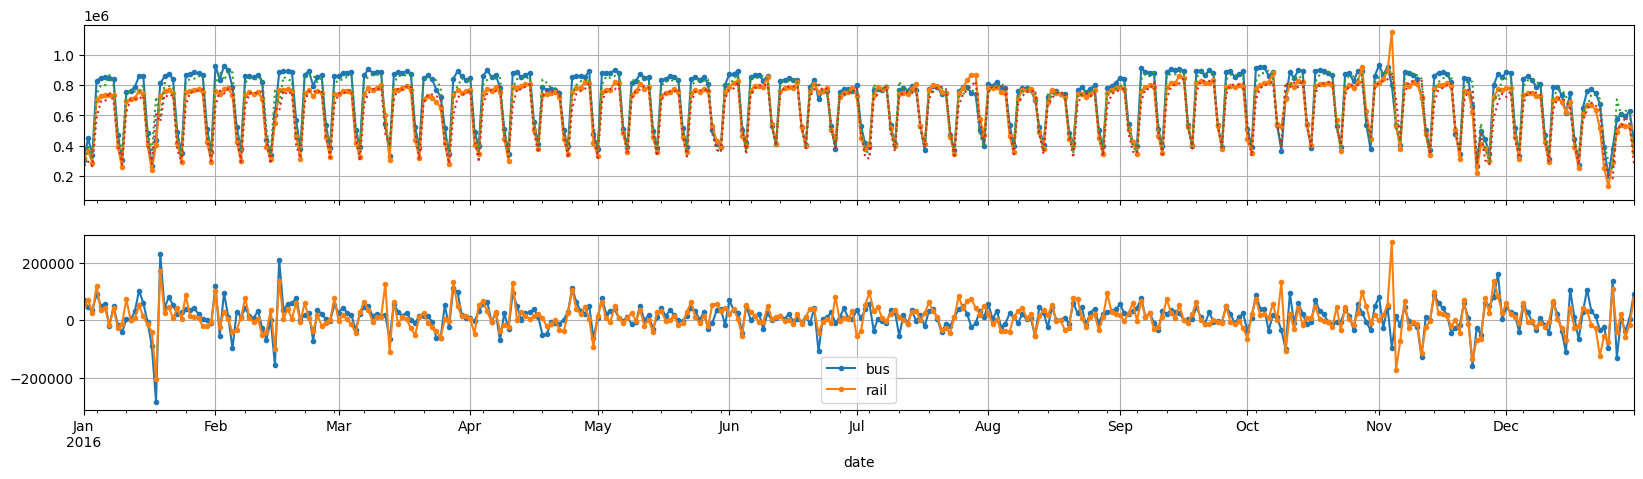

In [21]:
test_pred = model_frame7.predict(test_ds) * 1e6
test_pred = pd.DataFrame(test_pred, 
                         index=df_bus_rail_test.index[frame_length:], 
                         columns=df_bus_rail_test.columns)

df_bus_rail_test_inv = df_num[train_samples:][frame_length:] * 1e6
test_df_diff = df_bus_rail_test_inv - test_pred

fig, axs = plt.subplots(2, 1, sharex=True, figsize=(20, 5))

df_bus_rail_test_inv.plot(ax=axs[0], legend=False, marker=".") 
test_pred.plot(ax=axs[0], grid=True, legend=False, linestyle=":") 

test_df_diff[period].plot(ax=axs[1], grid=True, marker=".")

In [22]:
mape_7 = (test_df_diff / df_bus_rail_test_inv).abs().mean()
mape_7

bus     0.056305
rail    0.063182
dtype: float64

frame_length = 28

In [23]:
frame_length = 28

train_ds = tf.keras.utils.timeseries_dataset_from_array(
    df_train.to_numpy(),
    targets=df_num[:train_samples][frame_length:],
    sequence_length=frame_length,
    batch_size=32,
    shuffle=True,
    seed=42
)

test_ds = tf.keras.utils.timeseries_dataset_from_array(
    df_test.to_numpy(),
    targets=df_num[train_samples:][frame_length:],
    sequence_length=frame_length,
    batch_size=32
)

In [25]:
model_frame28 = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(64, return_sequences=True, input_shape=[None, 5]),
    tf.keras.layers.SimpleRNN(32),
    tf.keras.layers.Dense(2)
])

model_frame28.compile(loss=tf.keras.losses.Huber(),
                optimizer=tf.keras.optimizers.Nadam(0.01),
                metrics=['mae', 'mse'])

callbacks = [tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)]
model_frame28.fit(train_ds, epochs=200, validation_data=test_ds, callbacks=callbacks)

Epoch 1/200
151/151 ━━━━━━━━━━━━━━━━━━━━ 16s 52ms/step - loss: 0.0176 - mae: 0.0937 - mse: 0.0382 - val_loss: 0.0060 - val_mae: 0.0925 - val_mse: 0.0119
Epoch 2/200
151/151 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - loss: 0.0028 - mae: 0.0566 - mse: 0.0056 - val_loss: 0.0057 - val_mae: 0.0847 - val_mse: 0.0115
Epoch 3/200
151/151 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step - loss: 0.0027 - mae: 0.0551 - mse: 0.0054 - val_loss: 0.0028 - val_mae: 0.0541 - val_mse: 0.0055
Epoch 4/200
151/151 ━━━━━━━━━━━━━━━━━━━━ 7s 47ms/step - loss: 0.0022 - mae: 0.0499 - mse: 0.0044 - val_loss: 0.0044 - val_mae: 0.0780 - val_mse: 0.0089
Epoch 5/200
151/151 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - loss: 0.0021 - mae: 0.0486 - mse: 0.0043 - val_loss: 0.0027 - val_mae: 0.0564 - val_mse: 0.0053
Epoch 6/200
151/151 ━━━━━━━━━━━━━━━━━━━━ 8s 50ms/step - loss: 0.0019 - mae: 0.0452 - mse: 0.0038 - val_loss: 0.0016 - val_mae: 0.0394 - val_mse: 0.0033
Epoch 7/200
151/151 ━━━━━━━━━━━━━━━━━━━━ 8s 50ms/step - loss: 0.0019 - mae: 0.0451 - ms

65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step


<Axes: xlabel='date'>

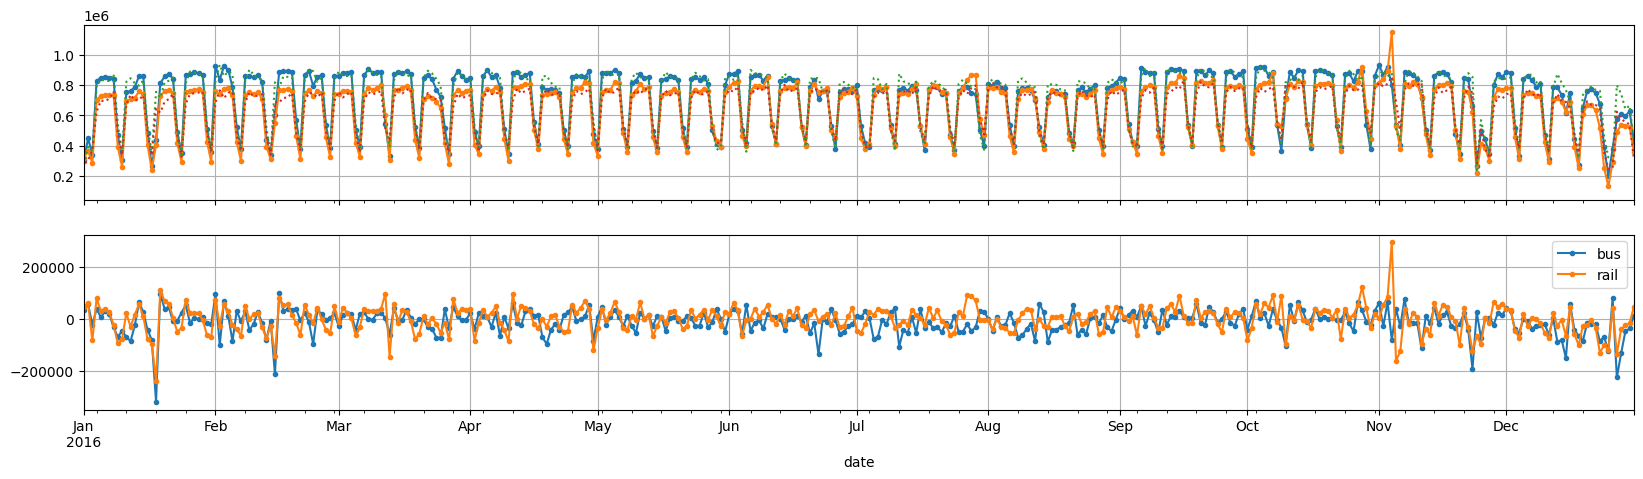

In [26]:
test_pred = model_frame28.predict(test_ds) * 1e6
test_pred = pd.DataFrame(test_pred, 
                         index=df_bus_rail_test.index[frame_length:], 
                         columns=df_bus_rail_test.columns)

df_bus_rail_test_inv = df_num[train_samples:][frame_length:] * 1e6
test_df_diff = df_bus_rail_test_inv - test_pred

fig, axs = plt.subplots(2, 1, sharex=True, figsize=(20, 5))

df_bus_rail_test_inv.plot(ax=axs[0], legend=False, marker=".") 
test_pred.plot(ax=axs[0], grid=True, legend=False, linestyle=":") 

test_df_diff[period].plot(ax=axs[1], grid=True, marker=".")

In [27]:
mape_28 = (test_df_diff / df_bus_rail_test_inv).abs().mean()
mape_28

bus     0.060693
rail    0.080903
dtype: float64

frame_length = 6 * 28

In [28]:
frame_length = 6 * 28

train_ds = tf.keras.utils.timeseries_dataset_from_array(
    df_train.to_numpy(),
    targets=df_num[:train_samples][frame_length:],
    sequence_length=frame_length,
    batch_size=32,
    shuffle=True,
    seed=42
)

test_ds = tf.keras.utils.timeseries_dataset_from_array(
    df_test.to_numpy(),
    targets=df_num[train_samples:][frame_length:],
    sequence_length=frame_length,
    batch_size=32
)

In [30]:
model_frame6m = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(64, return_sequences=True, input_shape=[None, 5]),
    tf.keras.layers.SimpleRNN(32),
    tf.keras.layers.Dense(2)
])

model_frame6m.compile(loss=tf.keras.losses.Huber(),
                optimizer=tf.keras.optimizers.Nadam(0.01),
                metrics=['mae', 'mse'])

callbacks = [tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)]
model_frame6m.fit(train_ds, epochs=200, validation_data=test_ds, callbacks=callbacks)

Epoch 1/200
147/147 ━━━━━━━━━━━━━━━━━━━━ 33s 157ms/step - loss: 0.0183 - mae: 0.0964 - mse: 0.0418 - val_loss: 0.0191 - val_mae: 0.1621 - val_mse: 0.0382
Epoch 2/200
147/147 ━━━━━━━━━━━━━━━━━━━━ 23s 156ms/step - loss: 0.0031 - mae: 0.0599 - mse: 0.0063 - val_loss: 0.0057 - val_mae: 0.0884 - val_mse: 0.0114
Epoch 3/200
147/147 ━━━━━━━━━━━━━━━━━━━━ 22s 151ms/step - loss: 0.0027 - mae: 0.0556 - mse: 0.0055 - val_loss: 0.0067 - val_mae: 0.0954 - val_mse: 0.0134
Epoch 4/200
147/147 ━━━━━━━━━━━━━━━━━━━━ 22s 150ms/step - loss: 0.0025 - mae: 0.0527 - mse: 0.0050 - val_loss: 0.0150 - val_mae: 0.1367 - val_mse: 0.0301
Epoch 5/200
147/147 ━━━━━━━━━━━━━━━━━━━━ 22s 151ms/step - loss: 0.0023 - mae: 0.0500 - mse: 0.0046 - val_loss: 0.0039 - val_mae: 0.0697 - val_mse: 0.0078
Epoch 6/200
147/147 ━━━━━━━━━━━━━━━━━━━━ 22s 150ms/step - loss: 0.0021 - mae: 0.0483 - mse: 0.0043 - val_loss: 0.0051 - val_mae: 0.0841 - val_mse: 0.0103
Epoch 7/200
147/147 ━━━━━━━━━━━━━━━━━━━━ 23s 154ms/step - loss: 0.0021 - mae

60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step


<Axes: xlabel='date'>

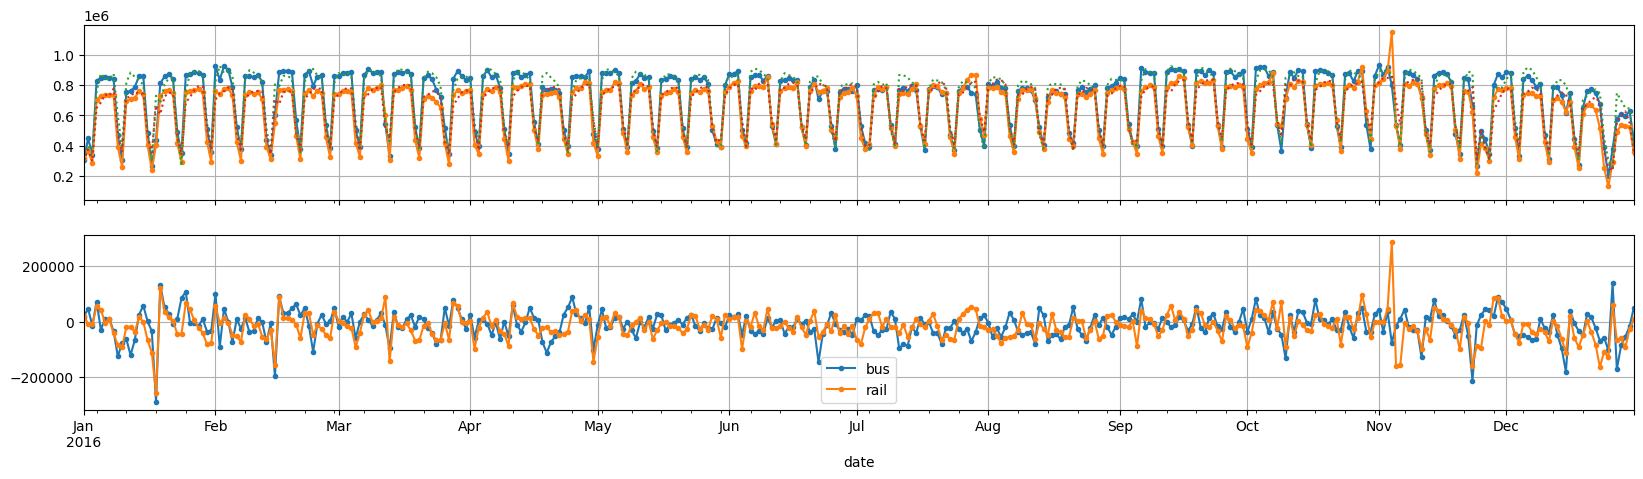

In [31]:
test_pred = model_frame6m.predict(test_ds) * 1e6
test_pred = pd.DataFrame(test_pred, 
                         index=df_bus_rail_test.index[frame_length:], 
                         columns=df_bus_rail_test.columns)

df_bus_rail_test_inv = df_num[train_samples:][frame_length:] * 1e6
test_df_diff = df_bus_rail_test_inv - test_pred

fig, axs = plt.subplots(2, 1, sharex=True, figsize=(20, 5))

df_bus_rail_test_inv.plot(ax=axs[0], legend=False, marker=".") 
test_pred.plot(ax=axs[0], grid=True, legend=False, linestyle=":") 

test_df_diff[period].plot(ax=axs[1], grid=True, marker=".")

In [32]:
mape_6m = (test_df_diff / df_bus_rail_test_inv).abs().mean()
mape_6m

bus     0.065134
rail    0.087329
dtype: float64

frame_length = 52 * 7

In [33]:
frame_length = 52 * 7

train_ds = tf.keras.utils.timeseries_dataset_from_array(
    df_train.to_numpy(),
    targets=df_num[:train_samples][frame_length:],
    sequence_length=frame_length,
    batch_size=32,
    shuffle=True,
    seed=42
)

test_ds = tf.keras.utils.timeseries_dataset_from_array(
    df_test.to_numpy(),
    targets=df_num[train_samples:][frame_length:],
    sequence_length=frame_length,
    batch_size=32
)

In [35]:
model_frame1y = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(64, return_sequences=True, input_shape=[None, 5]),
    tf.keras.layers.SimpleRNN(32),
    tf.keras.layers.Dense(2)
])

model_frame1y.compile(loss=tf.keras.losses.Huber(),
                optimizer=tf.keras.optimizers.Nadam(0.01),
                metrics=['mae', 'mse'])

callbacks = [tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)]
model_frame1y.fit(train_ds, epochs=200, validation_data=test_ds, callbacks=callbacks)

Epoch 1/200
141/141 ━━━━━━━━━━━━━━━━━━━━ 37s 223ms/step - loss: 0.0244 - mae: 0.1049 - mse: 0.0518 - val_loss: 0.0083 - val_mae: 0.1080 - val_mse: 0.0165
Epoch 2/200
141/141 ━━━━━━━━━━━━━━━━━━━━ 29s 208ms/step - loss: 0.0029 - mae: 0.0572 - mse: 0.0058 - val_loss: 0.0113 - val_mae: 0.1163 - val_mse: 0.0225
Epoch 3/200
141/141 ━━━━━━━━━━━━━━━━━━━━ 30s 209ms/step - loss: 0.0027 - mae: 0.0552 - mse: 0.0054 - val_loss: 0.0075 - val_mae: 0.1038 - val_mse: 0.0149
Epoch 4/200
141/141 ━━━━━━━━━━━━━━━━━━━━ 29s 205ms/step - loss: 0.0025 - mae: 0.0524 - mse: 0.0051 - val_loss: 0.0114 - val_mae: 0.1325 - val_mse: 0.0227
Epoch 5/200
141/141 ━━━━━━━━━━━━━━━━━━━━ 30s 210ms/step - loss: 0.0024 - mae: 0.0513 - mse: 0.0047 - val_loss: 0.0037 - val_mae: 0.0695 - val_mse: 0.0074
Epoch 6/200
141/141 ━━━━━━━━━━━━━━━━━━━━ 29s 205ms/step - loss: 0.0023 - mae: 0.0499 - mse: 0.0046 - val_loss: 0.0087 - val_mae: 0.1192 - val_mse: 0.0174
Epoch 7/200
141/141 ━━━━━━━━━━━━━━━━━━━━ 30s 212ms/step - loss: 0.0019 - mae

54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step


<Axes: xlabel='date'>

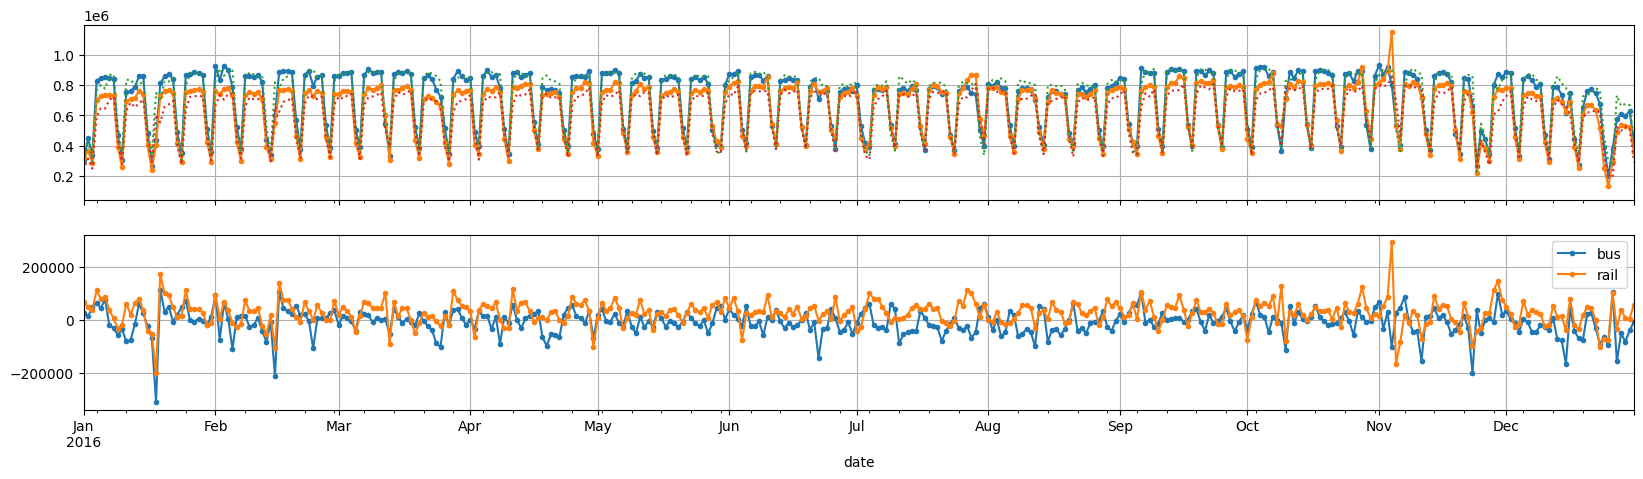

In [36]:
test_pred = model_frame1y.predict(test_ds) * 1e6
test_pred = pd.DataFrame(test_pred, 
                         index=df_bus_rail_test.index[frame_length:], 
                         columns=df_bus_rail_test.columns)

df_bus_rail_test_inv = df_num[train_samples:][frame_length:] * 1e6
test_df_diff = df_bus_rail_test_inv - test_pred

fig, axs = plt.subplots(2, 1, sharex=True, figsize=(20, 5))

df_bus_rail_test_inv.plot(ax=axs[0], legend=False, marker=".") 
test_pred.plot(ax=axs[0], grid=True, legend=False, linestyle=":") 

test_df_diff[period].plot(ax=axs[1], grid=True, marker=".")

In [37]:
mape_1y = (test_df_diff / df_bus_rail_test_inv).abs().mean()
mape_1y

bus     0.061145
rail    0.078310
dtype: float64

In [39]:
inxs_0 = pd.Series(['frame 7d', 
                    'frame 28d', 
                    'frame 6m', 
                    'frame 1y'
                    ]).repeat(2)

res = pd.concat([mape_7, mape_28, mape_6m, mape_1y])
res.name = 'MAPE RESULTS'
res.index = pd.MultiIndex.from_arrays([inxs_0, res.index])
res

frame 7d   bus     0.056305
           rail    0.063182
frame 28d  bus     0.060693
           rail    0.080903
frame 6m   bus     0.065134
           rail    0.087329
frame 1y   bus     0.061145
           rail    0.078310
Name: MAPE RESULTS, dtype: float64

## Task 1

да се имплементират следните функцията timeseries_dataset_from_array

In [14]:
reload(tf_data)
from tf_data import timeseries_dataset_from_array

my_series = [0, 1, 2, 3, 4, 5]
my_dataset = timeseries_dataset_from_array(
    my_series,
    targets=my_series[3:], 
    sequence_length=3,
    batch_size=2
)

list(my_dataset)

[(<tf.Tensor: shape=(2, 3), dtype=int32, numpy=
  array([[0, 1, 2],
         [1, 2, 3]], dtype=int32)>,
  <tf.Tensor: shape=(2,), dtype=int32, numpy=array([3, 4], dtype=int32)>),
 (<tf.Tensor: shape=(1, 3), dtype=int32, numpy=array([[2, 3, 4]], dtype=int32)>,
  <tf.Tensor: shape=(1,), dtype=int32, numpy=array([5], dtype=int32)>)]

In [16]:
reload(tf_data)
from tf_data import timeseries_dataset_from_array

rail_train = df['rail']

seq_length = 56
train_ds = timeseries_dataset_from_array(
    rail_train.to_numpy(),
    targets=rail_train[seq_length:],
    sequence_length=seq_length,
    batch_size=32,
    shuffle=True,
    seed=42
)

In [17]:
next(iter(train_ds))

(<tf.Tensor: shape=(32, 56), dtype=float64, numpy=
 array([[615948., 611182., 316867., ..., 608975., 632513., 609115.],
        [657966., 343099., 249540., ..., 648809., 680635., 713778.],
        [269253., 677343., 690269., ..., 618571., 596207., 335672.],
        ...,
        [598236., 616038., 625381., ..., 650805., 406577., 293680.],
        [617675., 631926., 642564., ..., 346881., 619299., 623390.],
        [413355., 683553., 695896., ..., 763277., 786864., 510149.]],
       shape=(32, 56))>,
 <tf.Tensor: shape=(32,), dtype=float64, numpy=
 array([633781., 711335., 172052., 628259., 648361., 349687., 347527.,
        621057., 609826., 574372., 314947., 711577., 586704., 651751.,
        616117., 591522., 590601., 394647., 690751., 590688., 422125.,
        631624., 236781., 733950., 640270., 728047., 611578., 469985.,
        314037., 623839., 627568., 371781.])>)

In [ ]:
seq_length = 56
train_ds = tf.keras.utils.timeseries_dataset_from_array(  # original!
    rail_train.to_numpy(),
    targets=rail_train[seq_length:],
    sequence_length=seq_length,
    batch_size=32,
    shuffle=True,
    seed=42
)

next(iter(train_ds))

(<tf.Tensor: shape=(32, 56), dtype=float64, numpy=
 array([[657786., 622633., 316086., ..., 648040., 683241., 653127.],
        [650877., 651230., 362376., ..., 586022., 594395., 597600.],
        [467927., 334490., 648312., ..., 732849., 745180., 708997.],
        ...,
        [371950., 805091., 831137., ..., 234285., 410220., 396926.],
        [600424., 632996., 627894., ..., 626565., 328467., 281620.],
        [355835., 258509., 636868., ..., 625991., 623937., 630151.]],
       shape=(32, 56))>,
 <tf.Tensor: shape=(32,), dtype=float64, numpy=
 array([656286., 591327., 415652., 346980., 774593., 390116., 398288.,
        601034., 683249., 607442., 616170., 399714., 707772., 595784.,
        810692., 564295., 447031., 216467., 778070., 451361., 594581.,
        310435., 187144., 709694., 353190., 627380., 585394., 663386.,
        320905., 312990., 621006., 331394.])>)

## Task 2

да се имплементират следните функции в класа Dataset

    flat_map
    window


In [7]:
reload(tf_data)
from tf_data import Dataset

for window_dataset in Dataset.range(6).window(4, shift=1):
    for element in window_dataset:
        print(f"{element}", end=" ")
    print()

0 1 2 3 
1 2 3 4 
2 3 4 5 
3 4 5 
4 5 
5 


In [8]:
reload(tf_data)
from tf_data import Dataset

for window_dataset in Dataset.range(6).window(4, shift=1, drop_remainder=True):
    for element in window_dataset:
        print(f"{element}", end=" ")
    print()

0 1 2 3 
1 2 3 4 
2 3 4 5 


In [9]:
reload(tf_data)
from tf_data import Dataset

dataset = Dataset.range(6).window(4, shift=1, drop_remainder=True)
dataset = dataset.flat_map(lambda window_dataset: window_dataset.batch(4))

for window_tensor in dataset:
    print(f"{window_tensor}")

[0 1 2 3]
[1 2 3 4]
[2 3 4 5]


In [10]:
reload(tf_data)
from tf_data import Dataset

def to_windows(dataset, length):
    dataset = dataset.window(length, shift=1, drop_remainder=True)
    return dataset.flat_map(lambda window_ds: window_ds.batch(length))


dataset = to_windows(Dataset.range(6), 4) # 3 inputs + 1 target = 4
dataset = dataset.map(lambda window: (window[:-1], window[-1]))
list(dataset.batch(2))

[(<tf.Tensor: shape=(2, 3), dtype=int32, numpy=
  array([[0, 1, 2],
         [1, 2, 3]], dtype=int32)>,
  <tf.Tensor: shape=(2,), dtype=int32, numpy=array([3, 4], dtype=int32)>),
 (<tf.Tensor: shape=(1, 3), dtype=int32, numpy=array([[2, 3, 4]], dtype=int32)>,
  <tf.Tensor: shape=(1,), dtype=int32, numpy=array([5], dtype=int32)>)]

## Task 3

да работи примера в учебника за подготовка на данните от timeseries по 2-та начина с нашите класове и функции

да се тества дали за този пример може вместо flat_map да се ползва map - да се тества с оригиналния клас

In [43]:
dataset = tf.data.Dataset.range(6).window(4, shift=1, drop_remainder=True)
dataset = dataset.map(lambda window_dataset: window_dataset.batch(4))

for window_tensor in dataset:
    for item in window_tensor:
        print(item)

tf.Tensor([0 1 2 3], shape=(4,), dtype=int64)
tf.Tensor([1 2 3 4], shape=(4,), dtype=int64)
tf.Tensor([2 3 4 5], shape=(4,), dtype=int64)


2026-02-15 19:11:55.795028: W tensorflow/core/framework/dataset.cc:993] Input of Window will not be optimized because the dataset does not implement the AsGraphDefInternal() method needed to apply optimizations.
2026-02-15 19:11:55.828611: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## Task 4

да се имплементира класа SimpleRNN

tanh функията може да се ползва наготово

In [20]:
reload(tf_model)
from tf_model import Sequential, SimpleRNN, Dense, Input

multivar_model = Sequential([
    Input([30, 2]),
    SimpleRNN(32),
    Dense(2) 
])

multivar_model.compile(optimizer='adam',
                     loss='mse',
                     metrics=['mse'])

In [18]:
reload(tf_data)
from tf_data import timeseries_dataset_from_array
bus_rail_train = df[['bus', 'rail']][:'2018-12'].astype(np.float32) / 1e6
bus_rail_test = df[['bus', 'rail']]['2019-01':'2019-12'].astype(np.float32) / 1e6
seq_length = 30

train_ds = timeseries_dataset_from_array(
    bus_rail_train.to_numpy(),
    targets=bus_rail_train[seq_length:],
    sequence_length=seq_length,
    batch_size=32,
    shuffle=True,
    seed=42
)

test_ds = timeseries_dataset_from_array(
    bus_rail_test.to_numpy(),
    targets=bus_rail_test[seq_length:],
    sequence_length=seq_length,
    batch_size=32,
    shuffle=True,
    seed=42
)

In [65]:
time_data = []
data_len = len(bus_rail_train)

for i in range(data_len - seq_length):
    start = i
    end   = start + seq_length

    part = bus_rail_train.iloc[start:end].to_numpy()
    time_data.append(part)

train_data = tf.convert_to_tensor(time_data)
y_train = tf.convert_to_tensor(bus_rail_train.iloc[seq_length:].to_numpy())

time_data = []
data_len = len(bus_rail_test)

for i in range(data_len - seq_length):
    start = i
    end   = start + seq_length

    part = bus_rail_test.iloc[start:end].to_numpy()
    time_data.append(part)

test_data = tf.convert_to_tensor(time_data)
y_test = tf.convert_to_tensor(bus_rail_test.iloc[seq_length:].to_numpy())

In [21]:
multivar_model.fit(train_ds, validation_data=(test_ds), epochs=5)

Epoch 1/5


0it [00:00, ?it/s]

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: name node, self, outside of any statement?
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: name node, self, outside of any statement?
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: name node, self, outside of any statement?
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 

205it [00:27,  7.34it/s]


    - loss: 0.08740530908107758 - meansquarederror: 0.08758482336997986
    - val_loss: 0.026182234287261963 - val_meansquarederror: 0.026182234287261963
    - Learning Rate: 0.001
Epoch 2/5


...

    - loss: 0.014639130793511868 - meansquarederror: 0.014623777940869331
    - val_loss: 0.014223795384168625 - val_meansquarederror: 0.014223795384168625
    - Learning Rate: 0.001
Epoch 4/5


205it [00:25,  8.19it/s]


    - loss: 0.012589903548359871 - meansquarederror: 0.012606839649379253
    - val_loss: 0.012872446328401566 - val_meansquarederror: 0.012872446328401566
    - Learning Rate: 0.001
Epoch 5/5


205it [00:25,  8.13it/s]


    - loss: 0.01153503730893135 - meansquarederror: 0.011549117974936962
    - val_loss: 0.012792408466339111 - val_meansquarederror: 0.012792408466339111
    - Learning Rate: 0.001


## Task 5

да се тестват примерите от книгата за обучение на прости модели нашата имплементация на класовете

    Dense layer
    SimpleRNN layer


In [4]:
bus_rail_train = df[['rail']][:'2018-12'].astype(np.float32) / 1e6
bus_rail_test = df[['rail']]['2019-01':'2019-12'].astype(np.float32) / 1e6
seq_length = 10

time_data = []
data_len = len(bus_rail_train)

for i in range(data_len - seq_length):
    start = i
    end   = start + seq_length

    part = bus_rail_train.iloc[start:end].to_numpy()
    time_data.append(part)

X_train = tf.convert_to_tensor(time_data)
y_train = tf.convert_to_tensor(bus_rail_train.iloc[seq_length:].to_numpy())

time_data = []
data_len = len(bus_rail_test)

for i in range(data_len - seq_length):
    start = i
    end   = start + seq_length

    part = bus_rail_test.iloc[start:end].to_numpy()
    time_data.append(part)

X_test = tf.convert_to_tensor(time_data)
y_test = tf.convert_to_tensor(bus_rail_test.iloc[seq_length:].to_numpy())

In [5]:
reload(tf_model)
from tf_model import Sequential, SimpleRNN, Dense, Input

model = Sequential([
    Input([seq_length, 1]),
    SimpleRNN(1)
])

model.compile(optimizer='adam',
                     loss='mse',
                     metrics=['mse'])

In [6]:
model.fit(X_train, y_train, epochs=5, validation_data=(X_test, y_test))

Epoch 1/5


  0%|          | 0/206 [00:00<?, ?it/s]

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: name node, self, outside of any statement?
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: name node, self, outside of any statement?
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: name node, self, outside of any statement?
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 

100%|██████████| 206/206 [00:01<00:00, 104.45it/s]


    - loss: 0.6345720291137695 - meansquarederror: 0.6345720887184143
    - val_loss: 0.6932867169380188 - val_meansquarederror: 0.6932867169380188
    - Learning Rate: 0.001
Epoch 2/5


...

    - loss: 0.6325581669807434 - meansquarederror: 0.6325579285621643
    - val_loss: 0.6932867169380188 - val_meansquarederror: 0.6932867169380188
    - Learning Rate: 0.001
Epoch 4/5


100%|██████████| 206/206 [00:00<00:00, 240.55it/s]


    - loss: 0.6324387788772583 - meansquarederror: 0.6324386596679688
    - val_loss: 0.6932867169380188 - val_meansquarederror: 0.6932867169380188
    - Learning Rate: 0.001
Epoch 5/5


100%|██████████| 206/206 [00:00<00:00, 254.50it/s]


    - loss: 0.6349088549613953 - meansquarederror: 0.6349088549613953
    - val_loss: 0.6932867169380188 - val_meansquarederror: 0.6932867169380188
    - Learning Rate: 0.001


In [7]:
reload(tf_model)
from tf_model import Sequential, SimpleRNN, Dense, Input


univar_model = Sequential([
    Input([seq_length, 1]),
    SimpleRNN(32),
    Dense(1)
])

univar_model.compile(optimizer='adam',
                     loss='mse',
                     metrics=['mse'])

univar_model.fit(X_train, y_train, epochs=5, validation_data=(X_test, y_test))

Epoch 1/5


  0%|          | 0/206 [00:00<?, ?it/s]

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: name node, self, outside of any statement?
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: name node, self, outside of any statement?
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: name node, self, outside of any statement?
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 

2026-02-15 21:28:42.982783: I external/local_xla/xla/service/service.cc:163] XLA service 0x715b7c0075a0 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
2026-02-15 21:28:42.982810: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): Host, Default Version
I0000 00:00:1771183723.027141    8285 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
100%|██████████| 206/206 [00:02<00:00, 70.28it/s] 


    - loss: 0.6601114273071289 - meansquarederror: 0.6601113080978394
    - val_loss: 0.0645427405834198 - val_meansquarederror: 0.0645427405834198
    - Learning Rate: 0.001
Epoch 2/5


...

    - loss: 0.030611542984843254 - meansquarederror: 0.030611544847488403
    - val_loss: 0.033594392240047455 - val_meansquarederror: 0.033594392240047455
    - Learning Rate: 0.001
Epoch 4/5


100%|██████████| 206/206 [00:01<00:00, 176.33it/s]


    - loss: 0.02079862356185913 - meansquarederror: 0.02079862356185913
    - val_loss: 0.026614880189299583 - val_meansquarederror: 0.026614880189299583
    - Learning Rate: 0.001
Epoch 5/5


100%|██████████| 206/206 [00:01<00:00, 204.70it/s]


    - loss: 0.015897998586297035 - meansquarederror: 0.015898000448942184
    - val_loss: 0.022868720814585686 - val_meansquarederror: 0.022868720814585686
    - Learning Rate: 0.001


In [9]:
reload(tf_model)
from tf_model import Sequential, SimpleRNN, Dense, Input

deep_model = Sequential([
    Input([seq_length, 1]),
    SimpleRNN(32, return_sequences=True),
    SimpleRNN(32, return_sequences=True),
    SimpleRNN(32),
    Dense(1)
])

deep_model.compile(optimizer='adam',
                     loss='mse',
                     metrics=['mse'])

deep_model.fit(X_train, y_train, epochs=20, validation_data=(X_test, y_test))


Epoch 1/20


  0%|          | 0/206 [00:00<?, ?it/s]

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: name node, self, outside of any statement?
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: name node, self, outside of any statement?
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: name node, self, outside of any statement?
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 

100%|██████████| 206/206 [00:05<00:00, 39.08it/s] 


    - loss: 0.061709482222795486 - meansquarederror: 0.06170947849750519
    - val_loss: 0.0238976888358593 - val_meansquarederror: 0.02389768697321415
    - Learning Rate: 0.001
Epoch 2/20


...

    - loss: 0.008819637820124626 - meansquarederror: 0.008819633163511753
    - val_loss: 0.01673087105154991 - val_meansquarederror: 0.016730869188904762
    - Learning Rate: 0.001
Epoch 19/20


100%|██████████| 206/206 [00:01<00:00, 137.84it/s]


    - loss: 0.008758986368775368 - meansquarederror: 0.008758984506130219
    - val_loss: 0.013710939325392246 - val_meansquarederror: 0.013710939325392246
    - Learning Rate: 0.001
Epoch 20/20


100%|██████████| 206/206 [00:01<00:00, 144.30it/s]


    - loss: 0.008578609675168991 - meansquarederror: 0.008578609675168991
    - val_loss: 0.013828758150339127 - val_meansquarederror: 0.01382876094430685
    - Learning Rate: 0.001


## Task 6

задача 2 от предишното домашно да се преработи като се ползват новите функции за подготовка на данните

## Task 7

да се имплементира модела SARIMA, като се ползва класа ARIMA в най елементарен вариант

    без да му се подава параметър d
    без да му се подават параметрите P, Q и D

съответно нашата имплементация на SARIMA трябва да има такива параметри

по-проста версия на задачата е да се се ползва параметър d на ARIMA

In [3]:
rail_ser = df['rail'][:'2018-12'].asfreq('D')
rail_ser

date
2001-01-01    126455.0
2001-01-02    501952.0
2001-01-03    536432.0
2001-01-04    550011.0
2001-01-05    557917.0
                ...   
2018-12-27    453029.0
2018-12-28    493961.0
2018-12-29    307105.0
2018-12-30    265310.0
2018-12-31    386058.0
Freq: D, Name: rail, Length: 6574, dtype: float64

In [4]:
rail_test = df['rail']['2019-01-01':'2019-01-30']
rail_test

date
2019-01-01    245852.0
2019-01-02    573542.0
2019-01-03    627781.0
2019-01-04    628514.0
2019-01-05    348257.0
2019-01-06    260556.0
2019-01-07    662470.0
2019-01-08    701693.0
2019-01-09    685444.0
2019-01-10    690162.0
2019-01-11    679115.0
2019-01-12    325219.0
2019-01-13    250222.0
2019-01-14    705571.0
2019-01-15    720095.0
2019-01-16    728048.0
2019-01-17    734929.0
2019-01-18    700006.0
2019-01-19    312424.0
2019-01-20    236744.0
2019-01-21    401503.0
2019-01-22    712125.0
2019-01-23    718899.0
2019-01-24    711300.0
2019-01-25    590674.0
2019-01-26    296063.0
2019-01-27    221081.0
2019-01-28    678810.0
2019-01-29    579917.0
2019-01-30     97917.0
Name: rail, dtype: float64

In [6]:
reload(SARIMA_model)
from SARIMA_model import SARIMA

custom = SARIMA(rail_ser, order=(1, 1, 1))
custom = custom.fit()
custom_pred = custom.forecast(steps=30)

y_true = df['rail'][custom_pred.index].asfreq('D')
# y_true = rail_test.values

'MAPE: ', np.abs((y_true - custom_pred) / y_true).mean()

('MAPE: ', np.float64(0.6399532884643668))

In [7]:
from statsmodels.tsa.arima.model import ARIMA

original = ARIMA(rail_ser, order=(1, 1, 1))
original = original.fit()
original_pred = original.forecast(steps=30)

y_true = df['rail'][original_pred.index].asfreq('D')
'MAPE: ', ((y_true - original_pred) / y_true).abs().mean()

('MAPE: ', np.float64(0.629806768767702))

In [8]:
reload(SARIMA_model)
from SARIMA_model import SARIMA

custom = SARIMA(rail_ser, order=(2, 2, 2))
custom = custom.fit()
custom_pred = custom.forecast(steps=30)

y_true = df['rail'][custom_pred.index].asfreq('D')
# y_true = rail_test.values

'MAPE: ', np.abs((y_true - custom_pred) / y_true).mean()

/home/zdravko/Machine_Learning_Intern/venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


('MAPE: ', np.float64(0.5801310881995841))

In [9]:
from statsmodels.tsa.arima.model import ARIMA

original = ARIMA(rail_ser, order=(2, 2, 2))
original = original.fit()
original_pred = original.forecast(steps=30)

y_true = df['rail'][original_pred.index].asfreq('D')
'MAPE: ', ((y_true - original_pred) / y_true).abs().mean()

('MAPE: ', np.float64(0.5844361122069304))

In [36]:
reload(SARIMA_model)
from SARIMA_model import SARIMA

custom = SARIMA(rail_ser, order=(0, 0, 0), seasonal_order=(0, 1, 0, 7))
custom = custom.fit()

custom_pred = custom.forecast(steps=30)
y_true = df['rail'][custom_pred.index].asfreq('D')

'MAPE: ', np.abs((y_true - custom_pred) / y_true).mean()

('MAPE: ', np.float64(0.4249548391095368))

In [35]:
from statsmodels.tsa.arima.model import ARIMA

original = ARIMA(rail_ser, order=(0, 0, 0), seasonal_order=(0, 1, 0, 7))
original = original.fit()
original_pred = original.forecast(steps=30)

y_true = df['rail'][original_pred.index].asfreq('D')
'MAPE: ', ((y_true - original_pred) / y_true).abs().mean()

('MAPE: ', np.float64(0.4249566065424295))

In [37]:
reload(SARIMA_model)
from SARIMA_model import SARIMA

custom = SARIMA(rail_ser, order=(0, 0, 0), seasonal_order=(0, 2, 0, 7))
custom = custom.fit()

custom_pred = custom.forecast(steps=30)
y_true = df['rail'][custom_pred.index].asfreq('D')

'MAPE: ', np.abs((y_true - custom_pred) / y_true).mean()

('MAPE: ', np.float64(1.5488434706464669))

In [39]:
from statsmodels.tsa.arima.model import ARIMA

original = ARIMA(rail_ser, order=(0, 0, 0), seasonal_order=(0, 2, 0, 7))
original = original.fit()
original_pred = original.forecast(steps=30)

y_true = df['rail'][original_pred.index].asfreq('D')
'MAPE: ', ((y_true - original_pred) / y_true).abs().mean()

('MAPE: ', np.float64(1.5464007965801276))

In [40]:
reload(SARIMA_model)
from SARIMA_model import SARIMA

custom = SARIMA(rail_ser, order=(1, 1, 1), seasonal_order=(0, 1, 0, 7))
custom = custom.fit()

custom_pred = custom.forecast(steps=30)
y_true = df['rail'][custom_pred.index].asfreq('D')

'MAPE: ', np.abs((y_true - custom_pred) / y_true).mean()

('MAPE: ', np.float64(0.4117820551256018))

In [41]:
from statsmodels.tsa.arima.model import ARIMA

original = ARIMA(rail_ser, order=(1, 1, 1), seasonal_order=(0, 1, 0, 7))
original = original.fit()
original_pred = original.forecast(steps=30)

y_true = df['rail'][original_pred.index].asfreq('D')
'MAPE: ', ((y_true - original_pred) / y_true).abs().mean()

('MAPE: ', np.float64(0.4117580650572762))

In [47]:
reload(SARIMA_model)
from SARIMA_model import SARIMA

custom = SARIMA(rail_ser, order=(0, 2, 0), seasonal_order=(0, 1, 0, 7))
custom = custom.fit()

custom_pred = custom.forecast(steps=30)
y_true = df['rail'][custom_pred.index].asfreq('D')

'MAPE: ', np.abs((y_true - custom_pred) / y_true).mean()

('MAPE: ', np.float64(9.787521838092463))

In [48]:
from statsmodels.tsa.arima.model import ARIMA

original = ARIMA(rail_ser, order=(0, 2, 0), seasonal_order=(0, 1, 0, 7))
original = original.fit()
original_pred = original.forecast(steps=30)

y_true = df['rail'][original_pred.index].asfreq('D')
'MAPE: ', ((y_true - original_pred) / y_true).abs().mean()

('MAPE: ', np.float64(9.725793223480483))

In [60]:
reload(SARIMA_model)
from SARIMA_model import SARIMA

custom = SARIMA(rail_ser, order=(1, 1, 1), seasonal_order=(1, 1, 1, 7))
custom = custom.fit()

custom_pred = custom.forecast(steps=30)
y_true = df['rail'][custom_pred.index].asfreq('D')

'MAPE: ', np.abs((y_true - custom_pred) / y_true).mean()

/home/zdravko/Machine_Learning_Intern/Machine_Learning/tensorflow/SARIMA_model.py:185: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  


('MAPE: ', np.float64(0.48717203686889976))

In [61]:
from statsmodels.tsa.arima.model import ARIMA

original = ARIMA(rail_ser, order=(1, 1, 1), seasonal_order=(1, 1, 1, 7))
original = original.fit()
original_pred = original.forecast(steps=30)

y_true = df['rail'][original_pred.index].asfreq('D')
'MAPE: ', ((y_true - original_pred) / y_true).abs().mean()

('MAPE: ', np.float64(0.3739767366457967))

In [59]:
reload(SARIMA_model)
from SARIMA_model import SARIMA

custom = SARIMA(rail_ser, order=(0, 0, 0), seasonal_order=(2, 1, 2, 7))
custom = custom.fit()

custom_pred = custom.forecast(steps=30)
y_true = df['rail'][custom_pred.index].asfreq('D')

'MAPE: ', np.abs((y_true - custom_pred) / y_true).mean()

/home/zdravko/Machine_Learning_Intern/Machine_Learning/tensorflow/SARIMA_model.py:185: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  


('MAPE: ', np.float64(0.3955949559392124))

In [58]:
from statsmodels.tsa.arima.model import ARIMA

original = ARIMA(rail_ser, order=(0, 0, 0), seasonal_order=(2, 1, 2, 7))
original = original.fit()
original_pred = original.forecast(steps=30)

y_true = df['rail'][original_pred.index].asfreq('D')
'MAPE: ', ((y_true - original_pred) / y_true).abs().mean()

('MAPE: ', np.float64(0.38259101876727))

In [14]:
sample = df['2019-03':'2019-05']['rail']
sample

date
2019-03-01    682969.0
2019-03-02    349392.0
2019-03-03    252150.0
2019-03-04    635353.0
2019-03-05    692945.0
                ...   
2019-05-27    256757.0
2019-05-28    694292.0
2019-05-29    717681.0
2019-05-30    735508.0
2019-05-31    738322.0
Name: rail, Length: 92, dtype: float64

<Axes: xlabel='date'>

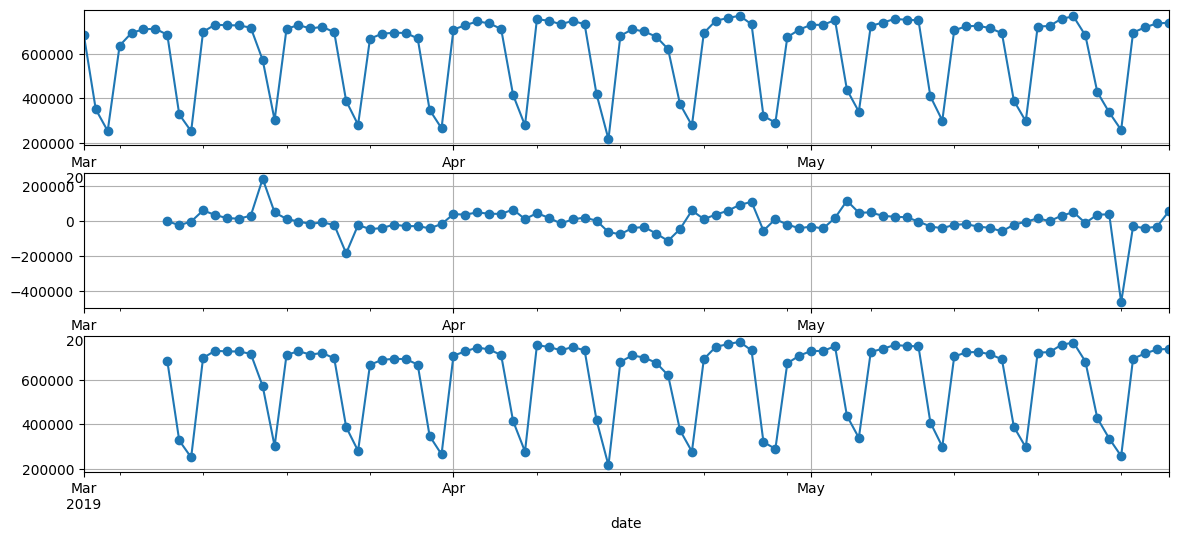

In [23]:
fig, ax = plt.subplots(3, 1, figsize=(14, 6))

sample.plot(ax=ax[0], marker='o', grid=True)
s_diff = sample - sample.shift(7) 
s_diff.plot(ax=ax[1], marker='o', grid=True)

s_integ = sample.shift(7) + s_diff
s_integ.plot(ax=ax[2], marker='o', grid=True)